In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Lucky number
random_state = 8

In [40]:
# Loading dataset
dataset = pd.read_csv('../../data/3-processed/phase2.csv')
dataset.head()

,sampleid,answerdate,sex,age,ageid,prefecture,area,married,child,hincome,...,mental_group,covid_group,k6_group3,k6_group2,phq9_%,gad_%,phq9_item9,phq9_si,audit_group,lsns_group
0,1759,2021-06-15,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0
1,3474,2021-06-15,1.0,58.0,10.0,27.0,5.0,2.0,2.0,4.0,...,1.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0
2,3793,2021-06-14,1.0,54.0,9.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,8488,2021-06-15,2.0,59.0,10.0,27.0,5.0,2.0,1.0,10.0,...,4.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
4,9703,2021-06-15,2.0,68.0,11.0,28.0,5.0,2.0,2.0,8.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
dataset.columns.tolist()

['sampleid',
 'answerdate',
 'sex',
 'age',
 'ageid',
 'prefecture',
 'area',
 'married',
 'child',
 'hincome',
 'pincome',
 'job',
 'student',
 'cell',
 'cellname',
 'number_fam',
 'schoolgrade',
 'yearsenrolled',
 'med_self',
 'medself_covid',
 'med_fam',
 'medfam_covid',
 'current_physical',
 'past_physical',
 'current_mental',
 'past_mental',
 'current_covid19',
 'past_covid19',
 'vaccine',
 'k6',
 'phq9',
 'gad7',
 'sss8',
 'ptgix(q8_2227)',
 'maia_1',
 'maia_2',
 'maia_3',
 'maia_4',
 'maia_5',
 'maia_6',
 'maia_7',
 'maia_8',
 'shs',
 'ucla',
 'lsns6',
 'audit',
 'exercise',
 'healthydiet',
 'favoriteactivity',
 'interaction_offline',
 'interaction_online',
 'pb_continuous',
 'pb_altruistic',
 'pb_avoidant',
 'trust_gov',
 'trust_sm',
 'vaccination_will',
 'pb_understanding',
 'optimism',
 'healthysleep',
 'deteriorationeconomy',
 'deteriorationinteract',
 'frustration',
 'covidanxiety',
 'covidsleepless',
 'difficultyliving',
 'difficultywork',
 'q7_22',
 'q7_23',
 'q7_24',
 'q

In [42]:
# Setting attributes
dataset = dataset[[
        'sex',                      # 1 - Male; 2 - Female
        'age',                      # Age    
        'married',                  # 1 - Unmarried; 2 - Married
        'child',                    # 1 - No children; 2 - With children
        'hincome',                  # 1 to 9, increasing annual household income
        'pincome',                  # Same categorization as HINCOME
        'number_fam',               # Number of cohabitants
        
        'job_group',                # 1 - Employed; 2 - Homemaker; 3 - Student; 4 - Unemployed; 5 - Others

        # 1 - Yes; 2 - No
        'med_self',                 # I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.)
        'medself_covid',            # As a medical worker, I am dealing with new corona patients.
        'med_fam',                  # Have a family member who is a healthcare worker
        'medfam_covid',             # There is a person in the family who is dealing with new corona patients as a medical worker.
        'current_physical',         # Whether the respondent has been treated for a physical illness in the past
        'past_physical',            # Whether the respondent is currently being treated for a mental disorder
        'current_mental',           # Whether the respondent has been treated for mental illness in the past
        'past_mental',              # Currently being treated for COVID-19
        'current_covid19',          # Currently undergoing treatment for COVID-19.
        'past_covid19',             # Have received treatment for COVID-19 in the past.
        
        # 1: Not at all true - 7: Very true
        'exercise',                 # I try to exercise to stay healthy (both indoors and outdoors). 
        'healthydiet',              # I ate meals with nutritional balance in mind.
        'healthysleep',             # My wake up and bedtimes were pretty consistent.
        'favoriteactivity',         # I engaged in hobbies and other activities that I could become passionate about.
        'interaction_offline',      # I interacted with family and friends in person (excluding work and classes).
        'interaction_online',       # Interacted with family and friends online via chat or video calls (excluding work or class).
        
        'pb_continuous',            # We continued to take preventive actions against the new coronavirus infection (wearing a mask, washing hands, limiting going out, etc.).
        'pb_altruistic',            # Voluntarily took preventive actions (wearing a mask, washing hands, limiting going out, etc.) to prevent the spread of the new coronavirus to family members and others.
        'pb_avoidant',              # To avoid social criticism and pressure, they took preventive actions (wearing masks, washing hands, limiting going out, etc.).
        'pb_understanding',         # They understood the necessity and importance of taking preventive actions.     
        'optimism',                 # I thought positively about the future.
        'deteriorationeconomy',     # The economic situation worsened.
        'deteriorationinteract',    # Relationships with close people such as family and friends have deteriorated.
        'frustration',              # Changes in my life sometimes made me irritable and angry.
        'covidanxiety',             # Watching the news about the new coronavirus made me feel nervous and anxious.
        'covidsleepless',           # I couldn't sleep because I was worried about catching the new coronavirus.
        'difficultyliving',         # Daily life was disrupted, with shortages of COVID-19 prevention supplies (masks, thermometers, etc.) and other daily necessities.
        'difficultywork',           # Changes in my lifestyle have caused problems with my work and studies.
 
        'k6',                       # Psychological stress
        'phq9',                     # Depression
        'lsns6',                    # Social Network
        'sss8',                     # Somatic symptoms
        #'shai',                     # Health anxiety
        'shs',                      # Subjective well-being
        
        'ucla'                      # Loneliness
    ]]
dataset

,sex,age,married,child,hincome,pincome,number_fam,job_group,med_self,medself_covid,...,covidanxiety,covidsleepless,difficultyliving,difficultywork,k6,phq9,lsns6,sss8,shs,ucla
0,1.0,57.0,2.0,2.0,4.0,3.0,2.0,1.0,2.0,2.0,...,4.0,5.0,4.0,4.0,11.0,8.0,9.0,15.0,4.50,27.0
1,1.0,58.0,2.0,2.0,4.0,4.0,3.0,1.0,2.0,2.0,...,4.0,1.0,1.0,1.0,6.0,6.0,7.0,2.0,2.75,31.0
2,1.0,54.0,2.0,2.0,4.0,3.0,2.0,1.0,2.0,2.0,...,1.0,1.0,1.0,3.0,0.0,2.0,0.0,5.0,4.00,26.0
3,2.0,59.0,2.0,1.0,10.0,1.0,1.0,2.0,2.0,2.0,...,5.0,1.0,5.0,1.0,6.0,4.0,3.0,5.0,4.75,34.0
4,2.0,68.0,2.0,2.0,8.0,1.0,4.0,2.0,2.0,2.0,...,4.0,1.0,1.0,1.0,0.0,0.0,19.0,0.0,3.75,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4587,2.0,30.0,1.0,1.0,4.0,4.0,1.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,4.0,4.0,2.0,1.0,4.00,28.0
4588,1.0,43.0,2.0,2.0,4.0,4.0,3.0,1.0,2.0,2.0,...,6.0,2.0,3.0,2.0,4.0,5.0,7.0,9.0,3.75,28.0
4589,1.0,60.0,2.0,1.0,3.0,2.0,2.0,1.0,2.0,2.0,...,3.0,2.0,2.0,2.0,6.0,5.0,16.0,8.0,4.00,25.0
4590,1.0,30.0,2.0,2.0,4.0,3.0,2.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,6.0,1.0,5.25,23.0


# Preprocessing

In [43]:
dataset_cleaned = dataset.copy()

In [44]:
dataset_cleaned.columns[dataset_cleaned.isna().any()].tolist()

[]

In [45]:
mode_value = dataset_cleaned.loc[~dataset_cleaned['hincome'].isin([10]) & dataset_cleaned['hincome'].notna(), 'hincome'].mode()[0]
dataset_cleaned['hincome'] = dataset_cleaned['hincome'].replace([10, np.nan], mode_value)

In [46]:
mode_value = dataset_cleaned.loc[~dataset_cleaned['pincome'].isin([10]) & dataset_cleaned['pincome'].notna(), 'pincome'].mode()[0]
dataset_cleaned['pincome'] = dataset_cleaned['pincome'].replace([10, np.nan], mode_value)

In [47]:
dataset_cleaned.columns[dataset_cleaned.isna().any()].tolist()

[]

In [48]:
dataset_cleaned = dataset.copy()

In [49]:
# Sex: 1 - Male; 2 - Female
column = 'sex'
def categories(x):
    if x == 1:
        return 'Male'
    elif x == 2:
        return 'Female'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# Married: 1 - Unmarried; 2 - Married
column = 'married'
def categories(x):
    if x == 1:
        return 'Unmarried'
    elif x == 2:
        return 'Married'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# Child: 1 - No children; 2 - With children
column = 'child'
def categories(x):
    if x == 1:
        return 'No children'
    elif x == 2:
        return 'With children'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# # Household Income Group
# column = 'hincome'
# def categories(x):
#     if x == 1:
#         return 'Less than 2 million'
#     elif x == 2:
#         return '2 million to less than 4 million'
#     elif x == 3:
#         return '4 million to less than 6 million'
#     elif x == 4:
#         return '6 million to less than 8 million'
#     elif x == 5:
#         return '8 million to less than 10 million'
#     elif x == 6:
#         return '10 million to less than 12 million'
#     elif x == 7:
#         return '12 million to less than 15 million'
#     elif x == 8:
#         return '15 million to less than 20 million'
#     elif x == 9:
#         return '20 million yen or more'
#     else:
#         return None
# dataset_cleaned[column] = dataset_cleaned[column].apply(categories)
# 
# # Personal Annual Income
# column = 'pincome'
# def categories(x):
#     if x == 1:
#         return 'Less than 2 million'
#     elif x == 2:
#         return '2 million to less than 4 million'
#     elif x == 3:
#         return '4 million to less than 6 million'
#     elif x == 4:
#         return '6 million to less than 8 million'
#     elif x == 5:
#         return '8 million to less than 10 million'
#     elif x == 6:
#         return '10 million to less than 12 million'
#     elif x == 7:
#         return '12 million to less than 15 million'
#     elif x == 8:
#         return '15 million to less than 20 million'
#     elif x == 9:
#         return '20 million yen or more'
#     else:
#         return None
# dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# Job Group
column = 'job_group'
def categories(x):
    if x == 1:
        return 'Employed'
    elif x == 2:
        return 'Homemaker'
    elif x == 3:
        return 'Student'
    elif x == 4: 
        return 'Unemployed'
    elif x == 5:
        return 'Others'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

In [50]:
dataset_cleaned 

,sex,age,married,child,hincome,pincome,number_fam,job_group,med_self,medself_covid,...,covidanxiety,covidsleepless,difficultyliving,difficultywork,k6,phq9,lsns6,sss8,shs,ucla
0,Male,57.0,Married,With children,4.0,3.0,2.0,Employed,2.0,2.0,...,4.0,5.0,4.0,4.0,11.0,8.0,9.0,15.0,4.50,27.0
1,Male,58.0,Married,With children,4.0,4.0,3.0,Employed,2.0,2.0,...,4.0,1.0,1.0,1.0,6.0,6.0,7.0,2.0,2.75,31.0
2,Male,54.0,Married,With children,4.0,3.0,2.0,Employed,2.0,2.0,...,1.0,1.0,1.0,3.0,0.0,2.0,0.0,5.0,4.00,26.0
3,Female,59.0,Married,No children,10.0,1.0,1.0,Homemaker,2.0,2.0,...,5.0,1.0,5.0,1.0,6.0,4.0,3.0,5.0,4.75,34.0
4,Female,68.0,Married,With children,8.0,1.0,4.0,Homemaker,2.0,2.0,...,4.0,1.0,1.0,1.0,0.0,0.0,19.0,0.0,3.75,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4587,Female,30.0,Unmarried,No children,4.0,4.0,1.0,Employed,2.0,2.0,...,1.0,1.0,1.0,1.0,4.0,4.0,2.0,1.0,4.00,28.0
4588,Male,43.0,Married,With children,4.0,4.0,3.0,Employed,2.0,2.0,...,6.0,2.0,3.0,2.0,4.0,5.0,7.0,9.0,3.75,28.0
4589,Male,60.0,Married,No children,3.0,2.0,2.0,Employed,2.0,2.0,...,3.0,2.0,2.0,2.0,6.0,5.0,16.0,8.0,4.00,25.0
4590,Male,30.0,Married,With children,4.0,3.0,2.0,Employed,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,6.0,1.0,5.25,23.0


In [51]:
columns = [
        'med_self',                 # I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.)
        'medself_covid',            # As a medical worker, I am dealing with new corona patients.
        'med_fam',                  # Have a family member who is a healthcare worker
        'medfam_covid',             # There is a person in the family who is dealing with new corona patients as a medical worker.
        'current_physical',         # Whether the respondent has been treated for a physical illness in the past
        'past_physical',            # Whether the respondent is currently being treated for a mental disorder
        'current_mental',           # Whether the respondent has been treated for mental illness in the past
        'past_mental',              # Currently being treated for COVID-19
        'current_covid19',          # Currently undergoing treatment for COVID-19.
        'past_covid19'              # Have received treatment for COVID-19 in the past.
]
 
def categories(x):
    if x == 1:
        return 'Yes'
    else:
        return 'No'
    
# Transform columns in categorical descriptions
for column in columns:
    dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

In [52]:
dataset_cleaned

,sex,age,married,child,hincome,pincome,number_fam,job_group,med_self,medself_covid,...,covidanxiety,covidsleepless,difficultyliving,difficultywork,k6,phq9,lsns6,sss8,shs,ucla
0,Male,57.0,Married,With children,4.0,3.0,2.0,Employed,No,No,...,4.0,5.0,4.0,4.0,11.0,8.0,9.0,15.0,4.50,27.0
1,Male,58.0,Married,With children,4.0,4.0,3.0,Employed,No,No,...,4.0,1.0,1.0,1.0,6.0,6.0,7.0,2.0,2.75,31.0
2,Male,54.0,Married,With children,4.0,3.0,2.0,Employed,No,No,...,1.0,1.0,1.0,3.0,0.0,2.0,0.0,5.0,4.00,26.0
3,Female,59.0,Married,No children,10.0,1.0,1.0,Homemaker,No,No,...,5.0,1.0,5.0,1.0,6.0,4.0,3.0,5.0,4.75,34.0
4,Female,68.0,Married,With children,8.0,1.0,4.0,Homemaker,No,No,...,4.0,1.0,1.0,1.0,0.0,0.0,19.0,0.0,3.75,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4587,Female,30.0,Unmarried,No children,4.0,4.0,1.0,Employed,No,No,...,1.0,1.0,1.0,1.0,4.0,4.0,2.0,1.0,4.00,28.0
4588,Male,43.0,Married,With children,4.0,4.0,3.0,Employed,No,No,...,6.0,2.0,3.0,2.0,4.0,5.0,7.0,9.0,3.75,28.0
4589,Male,60.0,Married,No children,3.0,2.0,2.0,Employed,No,No,...,3.0,2.0,2.0,2.0,6.0,5.0,16.0,8.0,4.00,25.0
4590,Male,30.0,Married,With children,4.0,3.0,2.0,Employed,Yes,Yes,...,1.0,1.0,1.0,1.0,0.0,0.0,6.0,1.0,5.25,23.0


In [53]:
categorical_features = [
    'sex',
    'married',
    'child',
    'job_group',
    'med_self',                 # I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.)
    'medself_covid',            # As a medical worker, I am dealing with new corona patients.
    'med_fam',                  # Have a family member who is a healthcare worker
    'medfam_covid',             # There is a person in the family who is dealing with new corona patients as a medical worker.
    'current_physical',         # Whether the respondent has been treated for a physical illness in the past
    'past_physical',            # Whether the respondent is currently being treated for a mental disorder
    'current_mental',           # Whether the respondent has been treated for mental illness in the past
    'past_mental',              # Currently being treated for COVID-19
    'current_covid19',          # Currently undergoing treatment for COVID-19.
    'past_covid19',             # Have received treatment for COVID-19 in the past.
]

In [54]:
initial_rows = len(dataset)

# Drop rows with NaN values (originally non-numeric values)
dataset_cleaned = dataset_cleaned.dropna()

row_count = len(dataset_cleaned)

print(f"Total number of rows: {row_count}")
print(f"Number of rows dropped: {initial_rows - row_count}")

Total number of rows: 4592
Number of rows dropped: 0


In [55]:
initial_rows = len(dataset_cleaned)

# Drop outliers in hincome and pincome
# https://medium.com/artificial-intelligence-101/handling-outliers-in-data-a-step-by-step-guide-using-python-be8471a021a9
Q1 = dataset_cleaned[['hincome', 'pincome']].quantile(0.25)
Q3 = dataset_cleaned[['hincome', 'pincome']].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering out outliers
dataset_cleaned = dataset_cleaned[~((dataset_cleaned[['hincome', 'pincome']] < lower_bound | 
                                    (dataset_cleaned[['hincome', 'pincome']] > upper_bound))).any(axis=1)]

# Get final number of rows
row_count = len(dataset_cleaned)

# Print number of dropped rows
print(f"Total number of rows: {row_count}")
print(f"Number of rows dropped: {initial_rows - row_count}")

Total number of rows: 4133
Number of rows dropped: 459


In [56]:
dataset_cleaned = pd.get_dummies(dataset_cleaned, columns=categorical_features, drop_first=True)

In [57]:
dataset_cleaned

,age,hincome,pincome,number_fam,exercise,healthydiet,healthysleep,favoriteactivity,interaction_offline,interaction_online,...,med_self_Yes,medself_covid_Yes,med_fam_Yes,medfam_covid_Yes,current_physical_Yes,past_physical_Yes,current_mental_Yes,past_mental_Yes,current_covid19_Yes,past_covid19_Yes
0,57.0,4.0,3.0,2.0,5.0,4.0,4.0,4.0,4.0,4.0,...,False,False,False,False,False,False,False,False,False,False
1,58.0,4.0,4.0,3.0,1.0,1.0,7.0,1.0,1.0,1.0,...,False,False,True,False,False,False,True,True,False,False
2,54.0,4.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,...,False,False,True,False,False,False,False,False,False,False
3,59.0,10.0,1.0,1.0,5.0,5.0,7.0,3.0,5.0,5.0,...,False,False,False,False,False,False,False,False,False,False
4,68.0,8.0,1.0,4.0,5.0,6.0,7.0,5.0,7.0,1.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4587,30.0,4.0,4.0,1.0,4.0,3.0,3.0,5.0,2.0,4.0,...,False,False,False,False,False,False,False,False,False,False
4588,43.0,4.0,4.0,3.0,2.0,3.0,6.0,5.0,2.0,2.0,...,False,False,False,False,False,False,False,False,False,False
4589,60.0,3.0,2.0,2.0,3.0,6.0,6.0,4.0,1.0,1.0,...,False,False,True,False,False,False,False,False,False,False
4590,30.0,4.0,3.0,2.0,7.0,7.0,5.0,5.0,5.0,1.0,...,True,True,False,False,False,False,False,False,False,False


# Train-Test Split

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [59]:
y = dataset_cleaned['ucla']
X = dataset_cleaned.drop(columns=['ucla'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [60]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [61]:
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Model Training

In [62]:
# https://www.geeksforgeeks.org/random-forest-regression-in-python/
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
baseline_model = RandomForestRegressor(random_state=random_state)
baseline_model.fit(X_train_scaled, y_train_scaled.ravel())

RandomForestRegressor(random_state=8)

In [64]:
def evaluate(model, X_test_scaled, y_test):
    y_pred_scaled = model.predict(X_test_scaled)
    
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
    
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Predicted vs Actual Values")
    plt.show()
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model.__class__.__name__}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")
    print("-" * 30)
    
    return r2

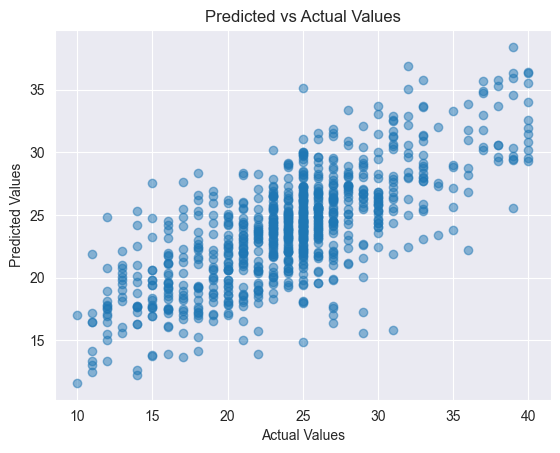

RandomForestRegressor:
  MAE: 3.1343
  MSE: 16.6371
  RMSE: 4.0789
  R²: 0.5377
------------------------------


0.5377124766155912

In [65]:
evaluate(baseline_model, X_test_scaled, y_test)

# SHAP for feature selection

In [66]:
import shap

In [67]:
explainer = shap.Explainer(baseline_model, X_train_scaled, feature_names=X_train.columns)
shap_values = explainer(X_train_scaled, check_additivity=False)

100%|===================| 3304/3306 [01:53<00:00]        

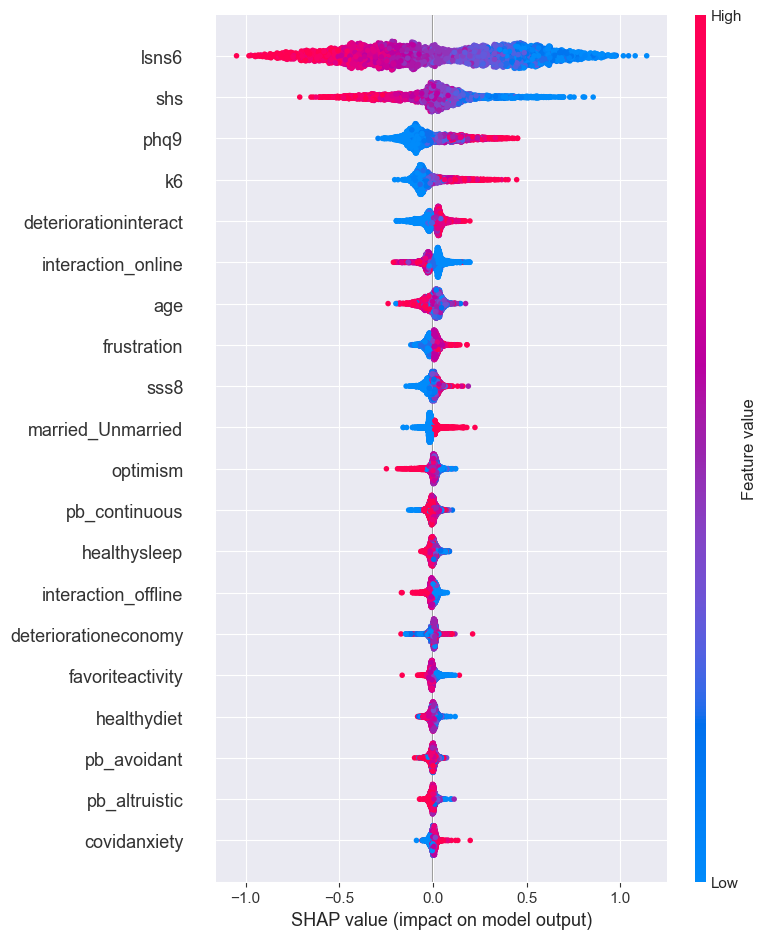

In [68]:
# Create summary plot
shap.summary_plot(shap_values, X_train_scaled)

# (Optional) Show the plot explicitly if needed
plt.show()

# Model Tuning

In [ ]:
import pprint
import joblib as job
import time

from sklearn.model_selection import GridSearchCV

pp = pprint.PrettyPrinter(indent=1)

In [ ]:
# Define hyperparameter space
n_estimators = [100, 250, 500, 1000]                       # Range of trees
max_features = [1, 2, 3, 4]                                # Feature selection
max_depth = [int(x) for x in np.linspace(10, 100, num=10)]
max_depth.append(None) # Depth
min_samples_split = [2, 5, 10, 15]                     # Control overfitting
min_samples_leaf = [1, 2, 4, 6]                       # Prevent overfitting
bootstrap = [True, False]                              # Sampling strategy
cv = 10                                         # Cross-validation folds

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

print('Hyperparameter search space')
pp.pprint(random_grid)

In [ ]:
# Set model to RandomForestRegressor
model = RandomForestRegressor(random_state=random_state)

In [ ]:
start_time = time.time()
grid_tuner = GridSearchCV(estimator=model, param_grid=random_grid, cv=cv, scoring='r2', 
                     verbose=6, return_train_score=True, n_jobs=10)
print('\nCross-validation via', grid_tuner)

# Fit the random search model
print("Fitting the Grid Search model...")
grid_tuner.fit(X_train_scaled, y_train_scaled.ravel())
print("Grid Search CV completed.")

end_time = time.time()
running_time = end_time - start_time
print('\nRandom Forest training time:', running_time, 's')

In [ ]:
# Save the model
model_name = type(grid_tuner).__name__
file_name = 'phase1_'+ model_name + '_' + time.strftime("%Y%m%d-%H%M%S") + '.mod'
file_save = file_name

print('Saving', model_name, 'model as', file_name, '...')
job.dump(grid_tuner, file_save) 

In [ ]:
# Load the model
file_model = ""
file_load = file_model

saved_model = job.load(file_load) 
tuner = saved_model

print('Best hyperparameters:')
pp.pprint(tuner.best_estimator_.get_params())

In [ ]:
## Plot CV results
def plot_cv(tuner):
    results = tuner.cv_results_
    cv_params = tuner.param_grid
    means_test = results['mean_test_score']
    stds_test = results['std_test_score']
    means_train = results['mean_train_score']
    stds_train = results['std_train_score']

    print(cv_params)
    fig, ax = plt.subplots(1, len(cv_params), sharex='none', sharey='all', figsize=(20,8), dpi=300)
    fig.suptitle('Hyperparameter Tuning')
    fig.text(0.04, 0.5, 'MEAN SCORE', va='center', rotation='vertical')

    scores = {}
    for i, (param, param_val) in enumerate(cv_params.items()):
        x, y1, e1, y2, e2 = [], [], [], [], []

        for v in param_val:
            mask_idx = results['param_'+param]==v
            v = str(v)

            m_train = np.mean(means_train[mask_idx])
            s_train = np.sqrt(np.mean(stds_train[mask_idx]**2))
            m_test = np.mean(means_test[mask_idx])    
            s_test = np.sqrt(np.mean(stds_test[mask_idx]**2))

            scores[param+'='+v+'_means_train'] = m_train
            scores[param+'='+v+'_stds_train'] = s_train    
            scores[param+'='+v+'_means_test'] = m_test
            scores[param+'='+v+'_stds_test'] = s_test
            print(param, "=", v, ":", m_test)

            x.append(v)
            y1.append(m_train)
            e1.append(s_train) 
            y2.append(m_test) 
            e2.append(s_test)

        ax[i].errorbar(x, y1, e1, linestyle='-', marker='^', label='Train')
        ax[i].errorbar(x, y2, e2, linestyle='--', marker='o', color='g', label='CV')
        ax[i].set_xlabel(param.upper())

    pp.pprint(scores)

    plt.legend()
    plt.show()

sns.set_style('dark')
plot_cv(saved_model)
print(tuner.cv_results_)

In [ ]:
## Evaluate model
print('Base model')
base_model = RandomForestRegressor(random_state=random_state)
base_model.fit(X_train_scaled, y_train_scaled.ravel())
base_accuracy = evaluate(base_model, X_test_scaled, y_test)

print('\nTuned model')
tuned_model = tuner.best_estimator_
tuned_accuracy = evaluate(tuned_model, X_test_scaled, y_test)

print('\nSaved model')
saved_accuracy = evaluate(saved_model.best_estimator_, X_test_scaled, y_test)

print('\nImprovement: {:0.4f}'.format(tuned_accuracy - base_accuracy))